In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

%matplotlib inline
#from brokenaxes import brokenaxes


plt.rc('lines', linewidth=4)
plt.rc('legend',fontsize=16)
plt.rc('axes',labelsize=16)
plt.rc('xtick',labelsize=12)
plt.rc('xtick',direction='in')
plt.rc('ytick',labelsize=12)
plt.rc('axes',labelsize=16)
plt.rc('ytick',direction='in')
plt.rc('figure',figsize=(8,6))


In [3]:
dat = pd.read_csv('psf 400.txt',    names=('i','x','y')     )
dat852 = pd.read_csv('psf 852.txt',    header =14 , delimiter = '\t')


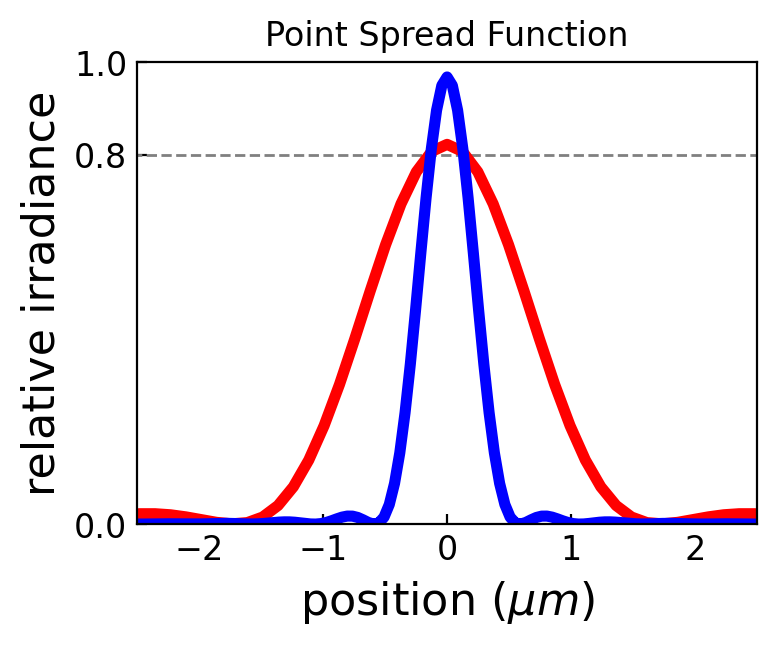

In [4]:
plt.figure(figsize =(4,3), dpi=200)
pmag = 125.9988
pmag852 = 7.57

plt.plot([-5,5],[.8,.8], color = 'grey', linestyle = '--', linewidth =1)
plt.plot(dat852['Position']/pmag852, dat852['Value'], color = 'r')

plt.plot(dat['x']/pmag, dat['y'], color = 'b')

#plt.plot([-.25,.25], [.5,.5])
plt.xlim(-2.5,2.5)

plt.ylim(0,1)
plt.yticks([0,.8,1])
plt.xlabel(r'position ($\mu m$)')
plt.ylabel(r'relative irradiance')
plt.title('Point Spread Function')
plt.savefig('psf.pdf')

D:/images/initial3V/20250703160816166_0.bmp
(3120, 4200)


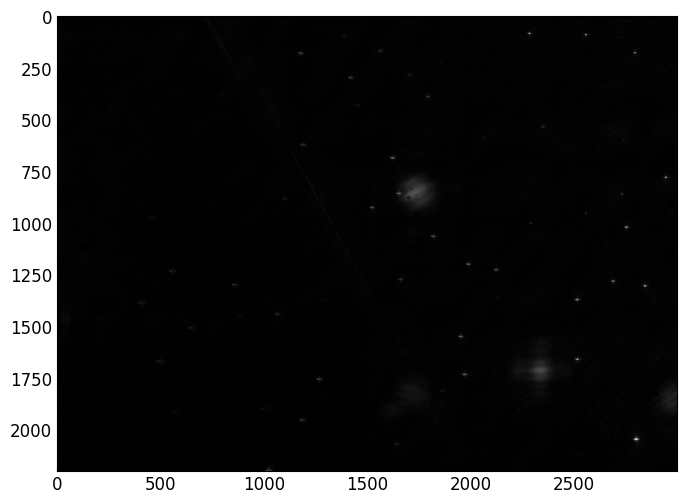

(2200, 3000)
(20, 3)


C:\Users\Tommy\AppData\Local\Temp\ipykernel_11584\365008251.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


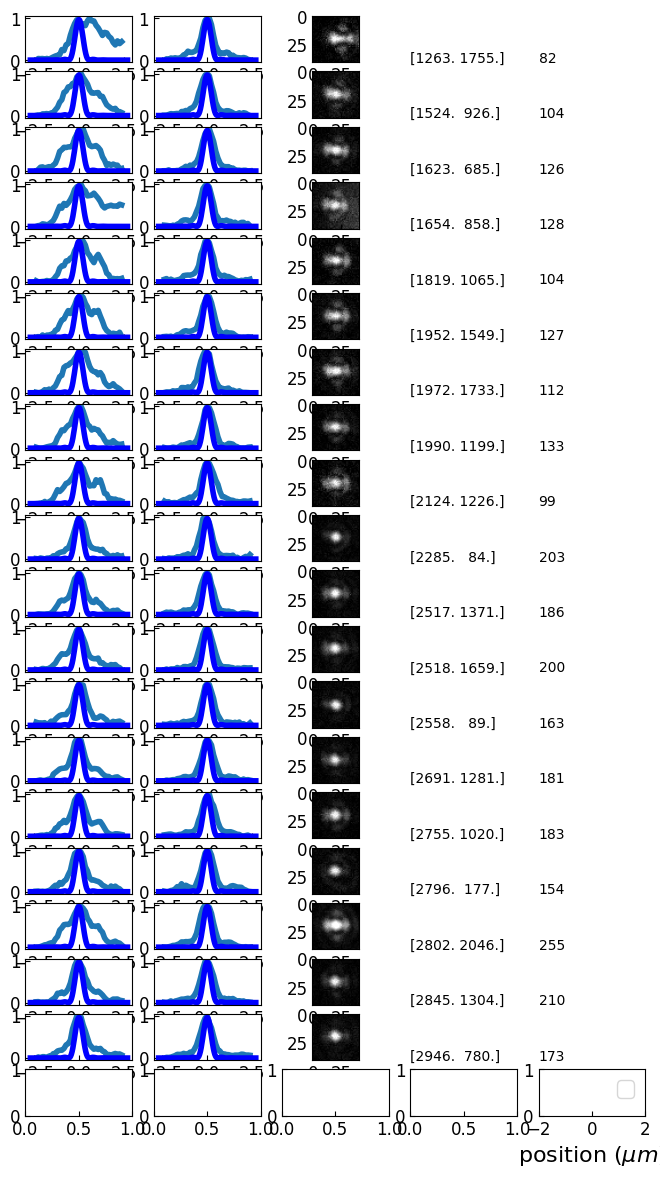

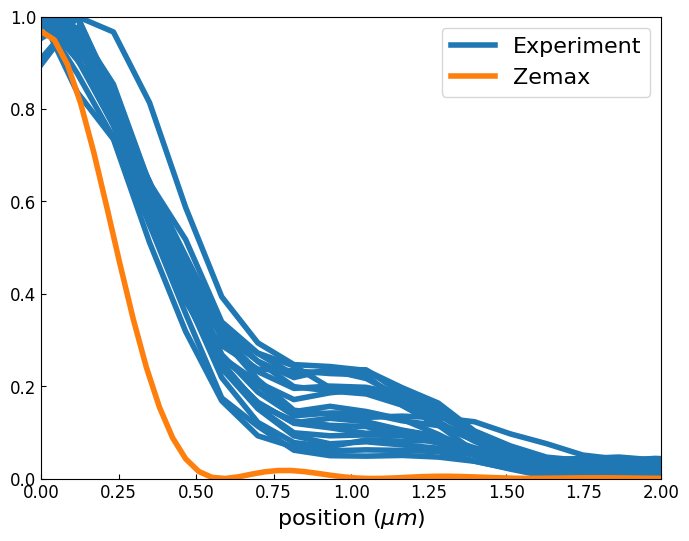

shape
(2200, 3000)


In [6]:
from PIL import Image
from operator import itemgetter


def radial_profile(data, center):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return np.unique(r),radialprofile 

import os


directory = os.fsencode("D:/images/initial3V/")
stack = []
all_x0s=[]
all_y0s=[]
for i,file in enumerate(sorted(os.listdir(directory))[10:11]):
    # plt.figure(dpi=200)
    filename = os.fsdecode(directory+file)
    im = np.array(Image.open(filename))
    print(filename)
    print(np.shape(im))
    im = im[400:2600,:3000] 
    plt.imshow(im, cmap= 'Greys_r')
    plt.show()

    print(im.shape)




    from skimage.feature import blob_dog, blob_log, blob_doh

    blobs = blob_dog(im, max_sigma=10, threshold=0.1)
    print(np.shape(blobs))
    

    blobs = sorted(blobs,key=itemgetter(1))
    # for b in blobs:
    #     plt.plot(np.mean(b[0]),np.mean(b[1]))
    
    l=0
    if np.shape(blobs)[0] > 0:
        fig, axs = plt.subplots(len(blobs)+1,5)
        margin = 20
        fig.set_figheight(15)
        

        x0s=[]
        y0s=[]
        for b in blobs:
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
                
            if bim.shape == (41,41):
            
            
                for a in [0,1]:
                    
                    X_ = np.linspace(0, bim.shape[0])
                    X_ = np.linspace(0, bim.shape[0]/8.5875, bim.shape[0])
                    X_ = X_ - np.mean(X_)
                    Y_ = np.sum(bim, axis = a)
                    Y_ = Y_ - np.min(Y_)
                    Y_ = Y_ / np.max(Y_)
                    axs[l,a].plot(X_,Y_)       
                    axs[l,a].plot(dat['x']/pmag, dat['y'], color = 'b', label = 'Zemax')
                axs[l,2].imshow(bim, cmap= 'Greys_r')
                axs[l,3].axis('off')
                axs[l,3].text(0,0,np.array((np.mean(b[1]), np.mean(b[0]))))
                axs[l,4].axis('off')
                axs[l,4].text(0,0,np.max(bim))
                x0s.append(int(np.mean(b[1])))
                y0s.append(int(np.mean(b[0])))
            else:
                axs[l,0].remove()
                axs[l,1].remove()
                axs[l,2].remove()
                axs[l,3].remove()
                axs[l,4].remove()
            plt.legend()
            plt.xlim(-2,2)
            plt.xlabel(r'position ($\mu m$)')
            l+=1
        plt.show()  
            
        all_x0s.append(x0s)
        all_y0s.append(y0s)
       

    for b in blobs:
            
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
            if bim.shape == (41,41):
             
                X_ = np.linspace(0, bim.shape[0])
                X_,Y_ = radial_profile(bim, (20,20))
                Y_ = Y_ - np.min(Y_)
                Y_ = Y_ / np.max(Y_)
                plt.plot(X_/8.5875,Y_, color = 'C0')
            else:
                continue
    plt.plot([],[], color = 'C0', label = 'Experiment')
    plt.plot(dat['x']/pmag, dat['y'], color = 'C1', label = 'Zemax')
    plt.legend()
    plt.xlim(0,2)
    plt.ylim(0,1)
    plt.xlabel(r'position ($\mu m$)')
    plt.show()
    print('shape')
    print(np.shape(im))



[1263, 1524, 1623, 1654, 1819, 1952, 1972, 1990, 2124, 2285, 2517, 2518, 2558, 2691, 2755, 2796, 2802, 2845, 2946] [1755, 926, 685, 858, 1065, 1549, 1733, 1199, 1226, 84, 1371, 1659, 89, 1281, 1020, 177, 2046, 1304, 780]
D:/images/initial3V/20250703160604060_0.bmp
2805


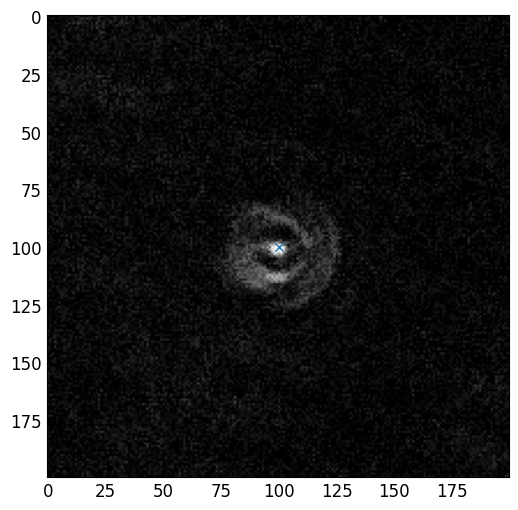

D:/images/initial3V/20250703160617600_0.bmp
2805


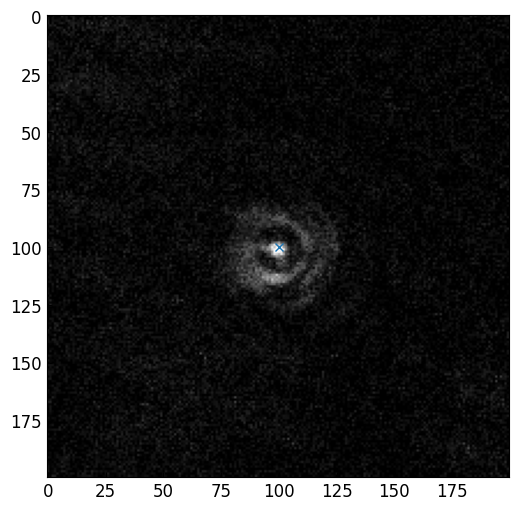

D:/images/initial3V/20250703160635298_0.bmp
2805


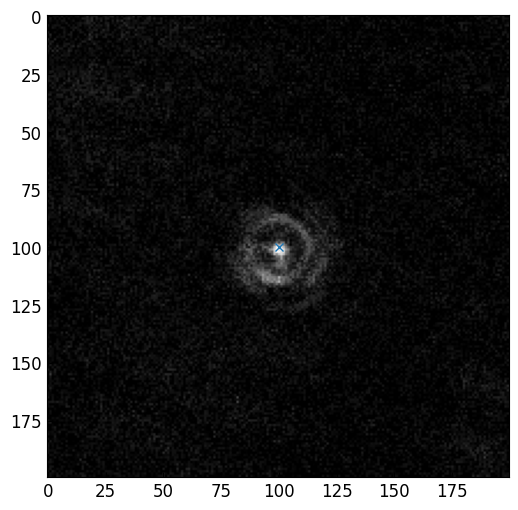

D:/images/initial3V/20250703160649125_0.bmp
2805


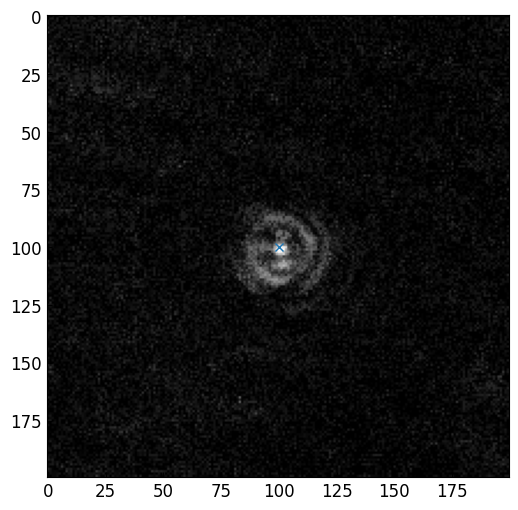

D:/images/initial3V/20250703160658221_0.bmp
2805


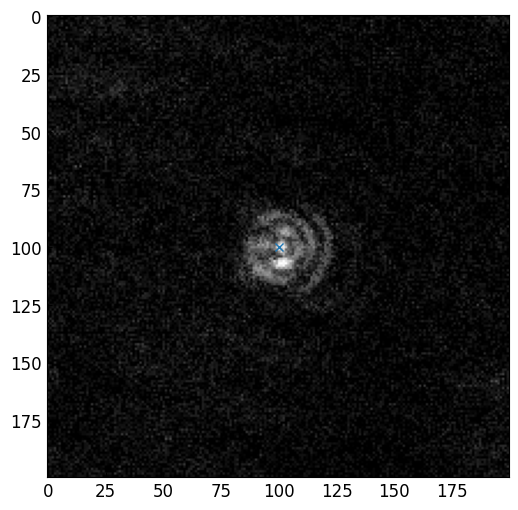

D:/images/initial3V/20250703160709899_0.bmp
2805


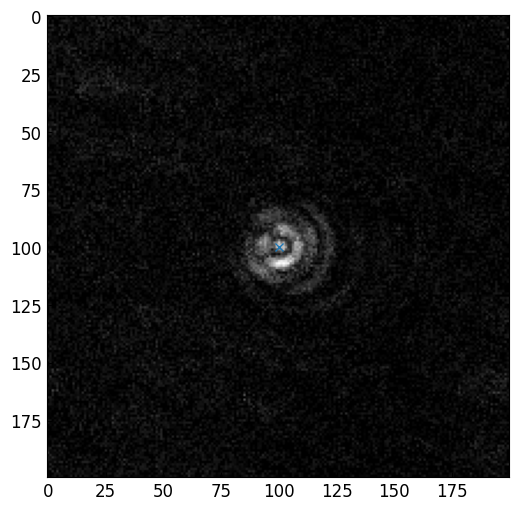

D:/images/initial3V/20250703160721288_0.bmp
2805


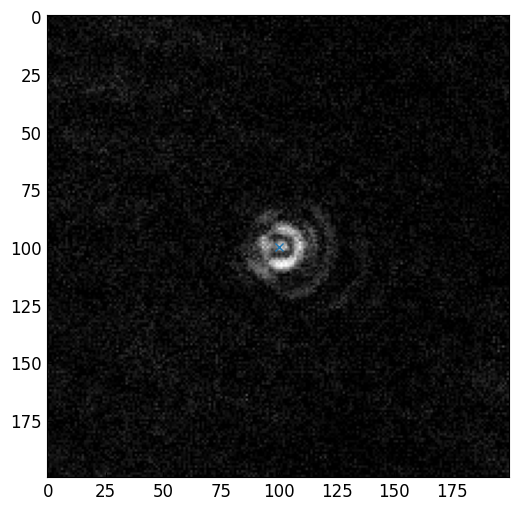

D:/images/initial3V/20250703160735115_0.bmp
2805


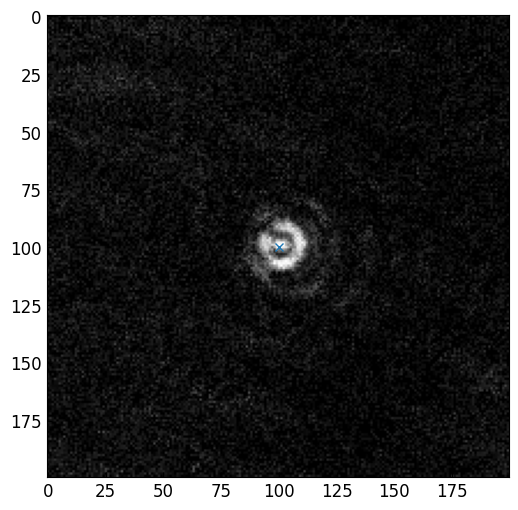

D:/images/initial3V/20250703160746934_0.bmp
2805


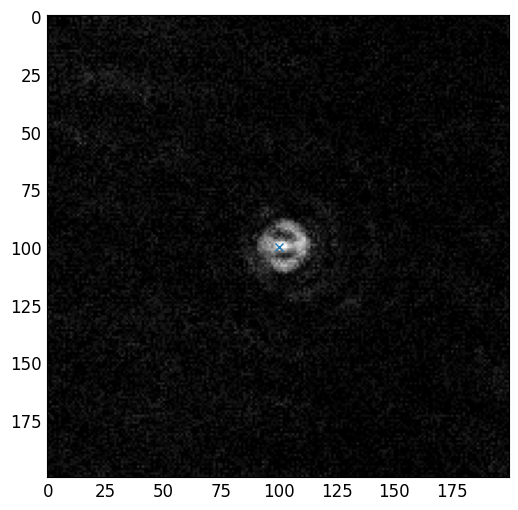

D:/images/initial3V/20250703160804060_0.bmp
2805


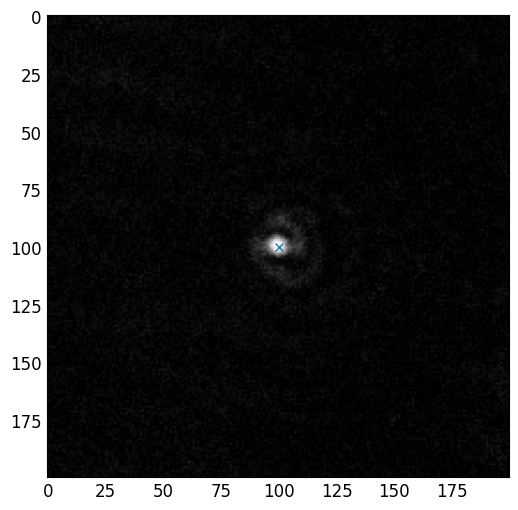

D:/images/initial3V/20250703160816166_0.bmp
2805


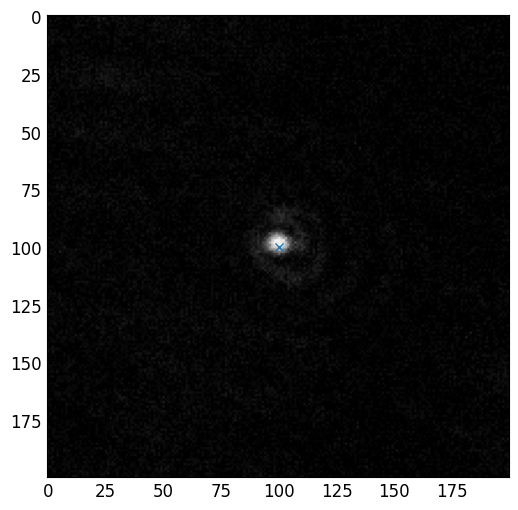

D:/images/initial3V/20250703160824115_0.bmp
2805


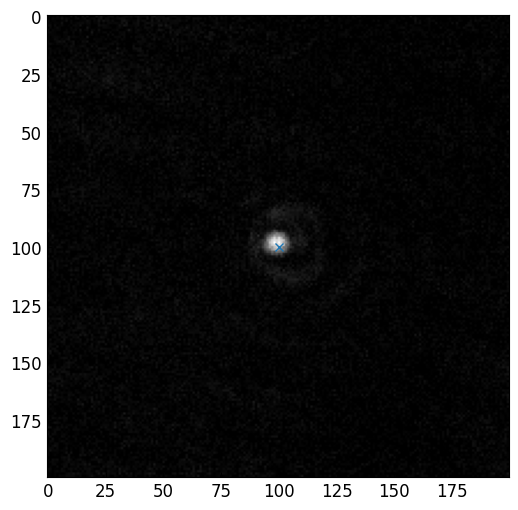

D:/images/initial3V/20250703160836508_0.bmp
2805


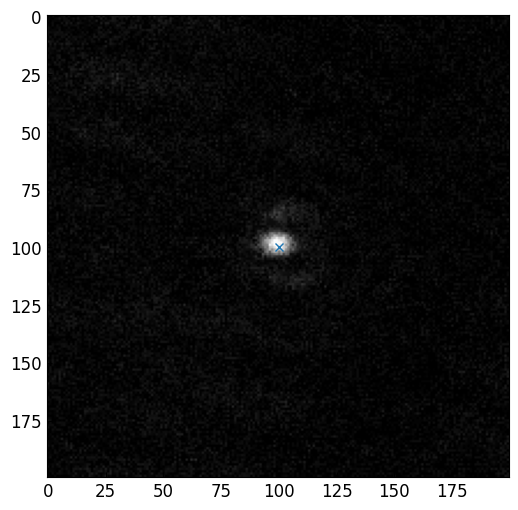

4.203703844203658


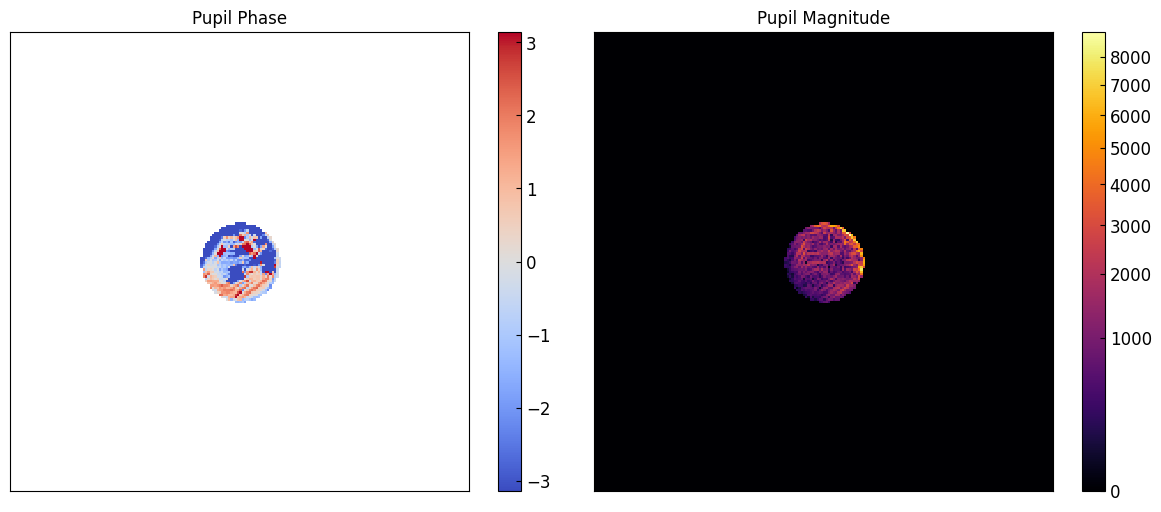

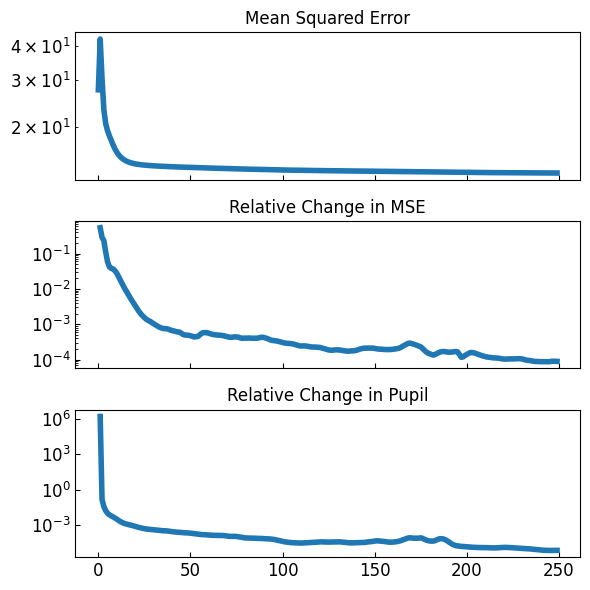

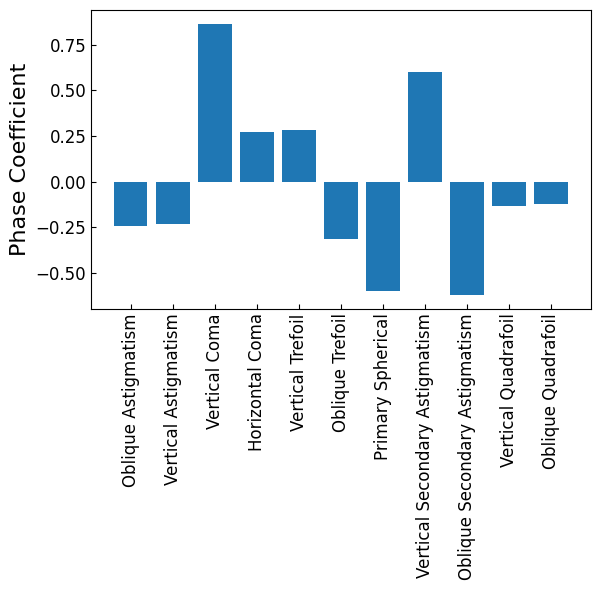

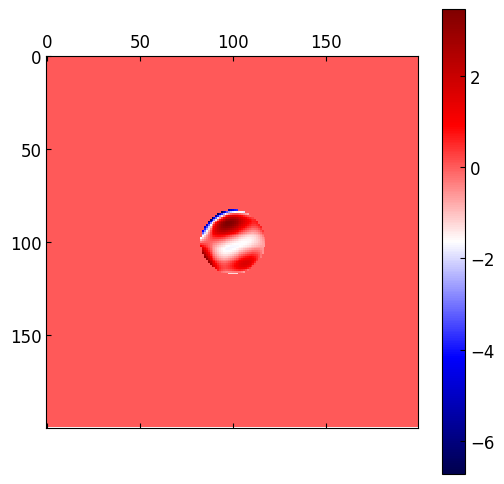

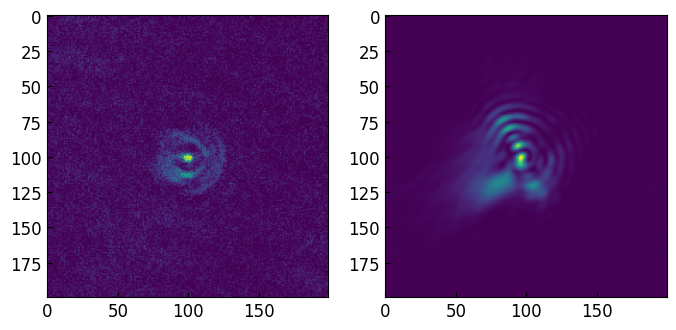

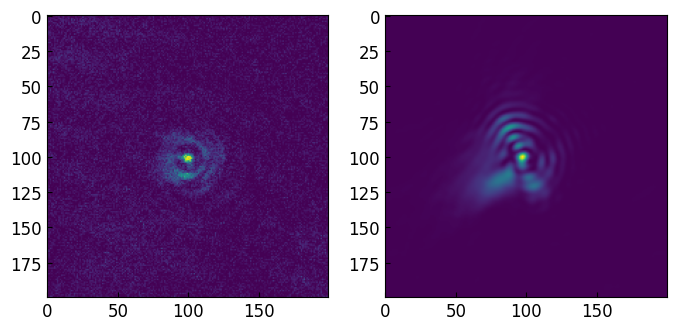

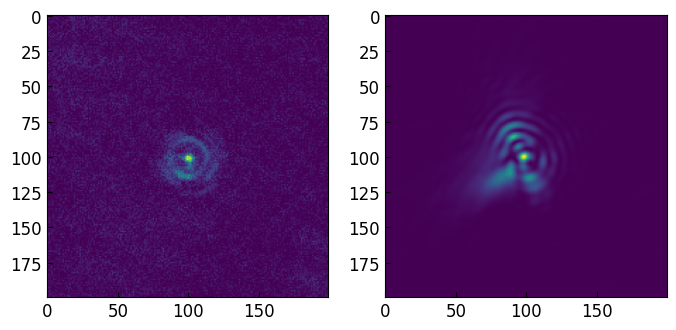

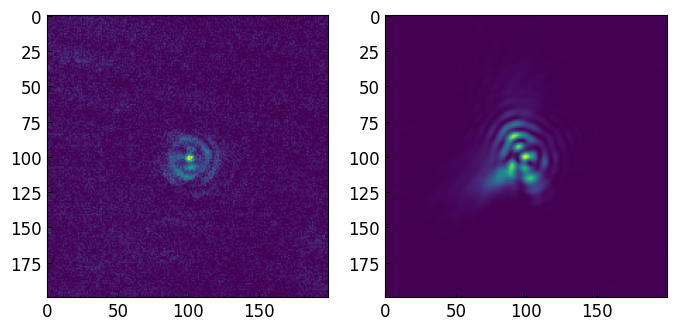

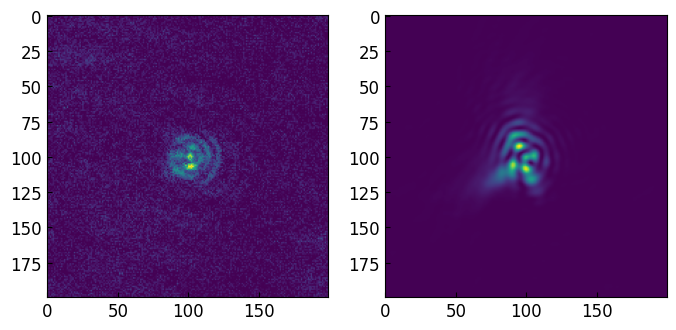

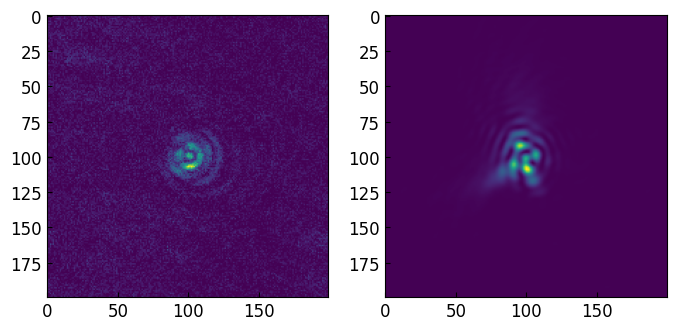

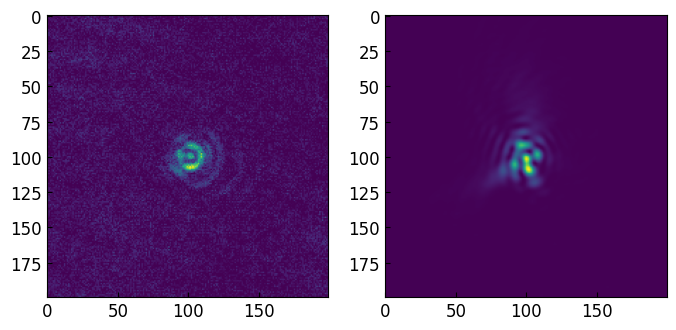

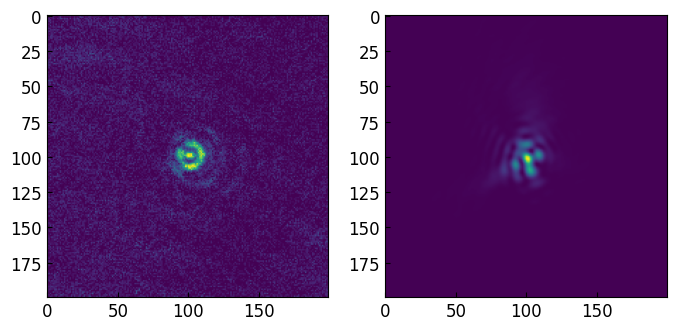

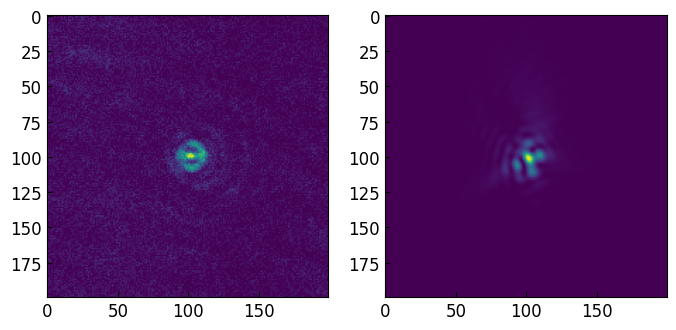

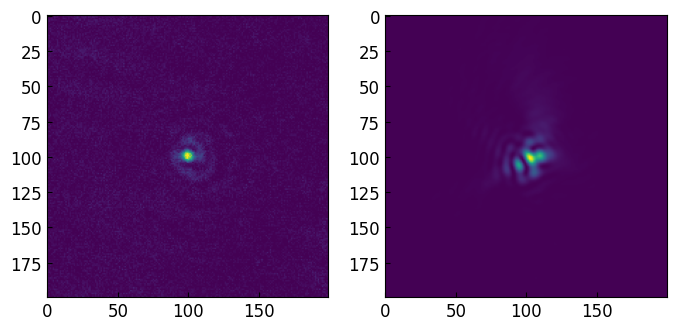

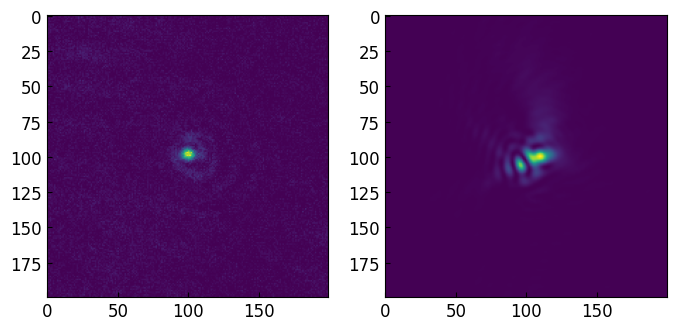

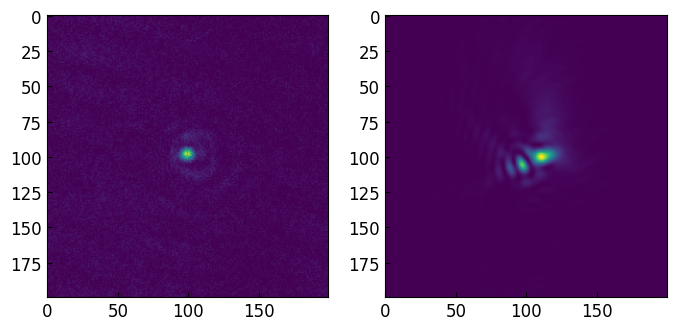

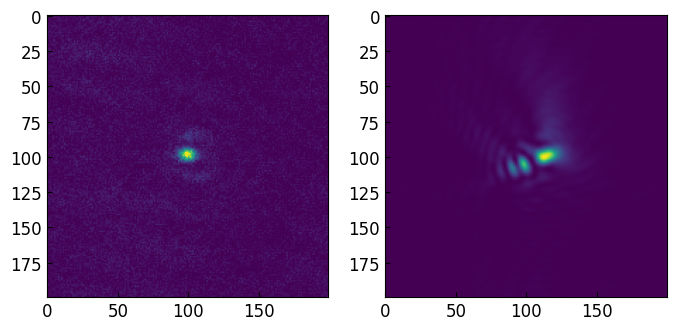

: 

In [ ]:
blob = 15
l=100

x0 = int(x0s[blob])+9
y0 = int(y0s[blob])-1

print(x0s,y0s)

stack = []

for i,file in enumerate(sorted(os.listdir(directory))[:-5]):


    filename = os.fsdecode(directory+file)

    print(filename)

    im = np.array(Image.open(filename))
    
    im = im[400:2600,:3000] 

    xshift = int(-0.9*i)

    yshift = int(0.3*i)
    print(x0)

    p = np.array(im)[y0-l+yshift:y0+l+yshift,x0-l+xshift:x0+l+xshift]

    plt.plot([l,], [l,],'x')

    stack.append(p)

    plt.imshow(p, cmap = 'Greys_r')

    plt.show()

stack = np.array(stack[:])

 

test_data =stack

 

#from pyotf import HanserPSF

from pyotf.phaseretrieval import *

from pyotf.utils import *

 

params = dict(

    size=test_data.shape[-1],

    zsize=test_data.shape[0],

    na=0.3,

    res=114  ,

    zres=100000/150*3,

    wl=399,

    ni=1.0,

    vec_corr="none",

    condition="none",

)
 

params["size"] = 512

junk = prep_data_for_PR(test_data, None, 1.05)


result = retrieve_phase(junk, params, 250, pupil_tol=np.nan, mse_tol=np.nan, phase_only=False)

result.plot()

result.plot_convergence()

zd_result = result.fit_to_zernikes(15)

zd_result.plot_named_coefs()

 

plt.matshow(zd_result.phase(slice(4, None, None)), cmap="seismic")

plt.colorbar()

print(result.rms_error)

plt.figure()

psf = result.generate_zd_psf()

for im,sim in zip(junk,psf):

    plt.subplot(1,2,1)

    plt.imshow(im)

   

    plt.subplot(1,2,2)

    plt.imshow(sim)

   

    

    plt.show()